# Phase-1

Installing libraries

In [ ]:
!pip install flwr scikit-learn pandas numpy matplotlib seaborn torch --quiet
print("Done!")

Done!


Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Libraries ready')

Libraries ready


Creating dataset

In [ ]:
np.random.seed(42)
N = 200000

#Types of attacks in CIC-IDS2017
labels = ['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Web Attack', 'FTP-Patator', 'SSH-Patator', 'DoS Slowloris']

weights = [0.60,0.12,0.10,0.05,0.04,0.03,0.03,0.03]
y = np.random.choice(labels, size=N, p=weights)
print(f"Created {N} samples")
print("Label Counts:")
print(pd.Series(y).value_counts())


Created 200000 samples
Label Counts:
BENIGN           119826
DDoS              24165
PortScan          19954
Bot               10091
Web Attack         8072
FTP-Patator        5979
DoS Slowloris      5971
SSH-Patator        5942
Name: count, dtype: int64


Generating the features

In [ ]:
feature_names = [
    'Flow Duration',        # how long the connection lasted
    'Total Fwd Packets',    # packets sent forward
    'Total Bwd Packets',    # packets sent back
    'Fwd Packet Length Max',# max size of forward packets
    'Bwd Packet Length Max',# max size of backward packets
    'Flow Bytes/s',         # data rate
    'Flow Packets/s',       # packet rate
    'Flow IAT Mean',        # avg time between packets
    'Fwd PSH Flags',        # TCP push flag count
    'Packet Length Mean',   # average packet size
    'Packet Length Std',    # variation in packet size
    'Active Mean',          # avg time flow was active
    'Idle Mean',            # avg time flow was idle
    'SYN Flag Count',       # TCP SYN flags (used in attacks)
    'RST Flag Count'        # TCP RST flags
]

X = np.zeros((N, len(feature_names)))

for i, label in enumerate(y):
    if label == 'BENIGN':
        X[i] = np.abs(np.random.normal(
            [5000, 10, 8, 200, 180, 5000, 20, 300, 0, 80, 30, 400, 200, 1, 0],
            scale=500))
    elif label == 'DDoS':
        X[i] = np.abs(np.random.normal(
            [100, 500, 2, 800, 50, 500000, 800, 5, 1, 800, 10, 10, 5, 500, 100],
            scale=50))
    elif label == 'PortScan':
        X[i] = np.abs(np.random.normal(
            [200, 1, 1, 60, 0, 3000, 50, 200, 0, 60, 0, 100, 300, 1, 1],
            scale=20))
    else:
        X[i] = np.abs(np.random.normal(
            [3000, 15, 10, 300, 250, 8000, 30, 250, 0, 100, 40, 300, 150, 2, 1],
            scale=300))

df = pd.DataFrame(X, columns=feature_names)
df['Label'] = y

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200000, 16)


,Flow Duration,Total Fwd Packets,Total Bwd Packets,Fwd Packet Length Max,Bwd Packet Length Max,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Fwd PSH Flags,Packet Length Mean,Packet Length Std,Active Mean,Idle Mean,SYN Flag Count,RST Flag Count,Label
0,4831.421017,876.933093,52.611151,256.934741,147.524167,4562.742895,525.538405,271.356667,149.479456,104.299204,235.797148,133.401316,123.728548,645.721308,206.133933,BENIGN
1,3123.164093,366.457346,342.930183,141.530101,708.563998,7983.662500,169.528867,465.132675,273.695854,169.074187,434.002168,710.301478,266.333600,465.194167,588.553877,SSH-Patator
2,197.797092,15.995973,25.560174,90.869997,17.739792,3014.272029,49.990506,221.218162,19.974588,41.469211,4.134364,108.321763,293.895301,25.871971,40.145740,PortScan
3,5604.199872,451.603658,29.480898,62.740115,15.358822,4785.527159,572.299922,172.293946,355.489287,173.722727,974.291690,1133.499358,463.451078,427.815670,213.606018,BENIGN
4,5515.895836,680.472673,702.505841,929.240049,626.282317,5250.542009,357.715350,1069.010278,345.352405,284.470822,436.034074,163.804450,215.386736,558.719686,567.722314,BENIGN


Visualize the Data


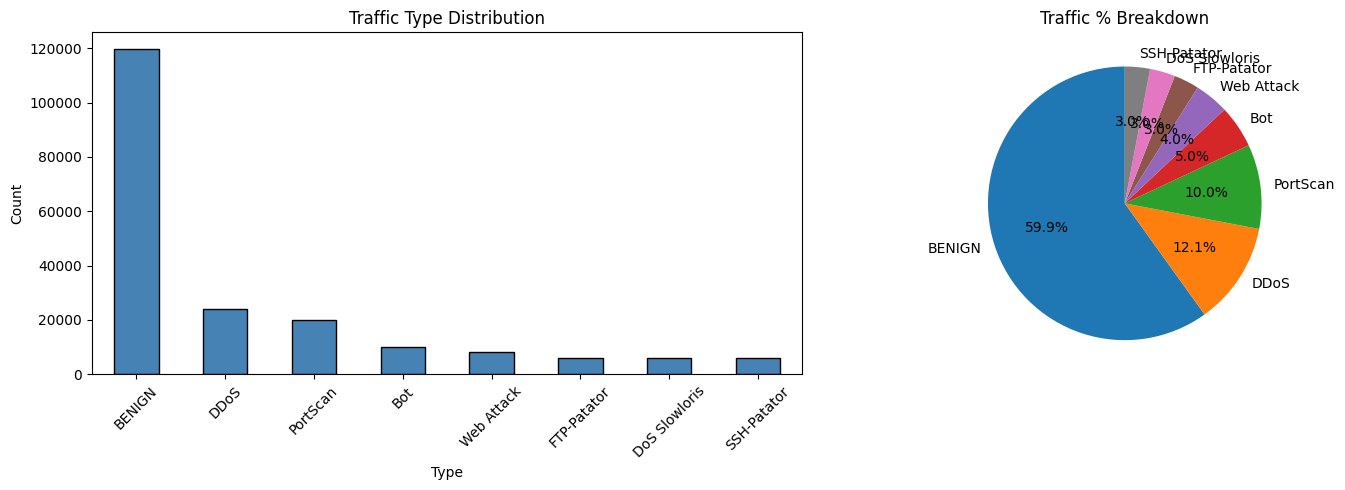

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count of each label
counts = df['Label'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Traffic Type Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Traffic % Breakdown')

plt.tight_layout()
plt.show()

# Phase-2


Check for Problems in the data


In [ ]:
print("=== Data Quality Check ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {df.shape[1]}")

#Checking the missing values
missing = df.isnull().sum().sum()
print(f"\n Missing values: {missing}")

#Checking for infinite values
inf_vals = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"Infinite values: {inf_vals}")

#Checking for Duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicated rows: {dupes}")

=== Data Quality Check ===
Total rows: 200000
Total columns: 16

 Missing values: 0
Infinite values: 0
Duplicated rows: 0


Fixing of problems (infinite and NaN values which crashes the models most of the times)

In [ ]:
df.replace([np.inf , -np.inf], np.nan, inplace=True)
df.fillna(0, inplace = True) #replacing the values of Inf with NaN then with 0
df.drop_duplicates(inplace=True)
print(f"Data cleaned!")
print(f"Rows remaining: {len(df)}")

Data cleaned!
Rows remaining: 200000


Encoding of labels


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label_Encoded'] = le.fit_transform(df['Label'])

print("Label Mapping:")
for i, name in enumerate(le.classes_):
  print(f"{name} -> {i}")

Label Mapping:
BENIGN -> 0
Bot -> 1
DDoS -> 2
DoS Slowloris -> 3
FTP-Patator -> 4
PortScan -> 5
SSH-Patator -> 6
Web Attack -> 7


Separate features from labels


In [ ]:
#X all feature columns (input of model)
#Y the label column (predictions)

X = df[feature_names].values
Y = df['Label_Encoded'].values

print(f"X shape: {X.shape} <- (rows, features)")
print(f"Y shape: {Y.shape} <- (rows,)")
print(f"Number of classes: {len(le.classes_)}")

X shape: (200000, 15) <- (rows, features)
Y shape: (200000,) <- (rows,)
Number of classes: 8


Normalize the features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - Flow Bytes/s stats:")
print(f" Mean: {X[:, 5].mean():.2f}, Std: {X[:, 5].std():.2f}")

print("\nAfter scaling - Flow Bytes/s stats:")
print(f" Mean: {X_scaled[:, 5].mean():.2f}, Std: {X_scaled[:, 5].std():.2f}")

Before scaling - Flow Bytes/s stats:
 Mean: 65149.20, Std: 161212.18

After scaling - Flow Bytes/s stats:
 Mean: 0.00, Std: 1.00


Splitting into Federated Clients

In [ ]:
NUM_CLIENTS = 5

#shuffling of data
indices = np.random.permutation(len(X_scaled))
X_scaled = X_scaled[indices]
y = y[indices]

#Split evenly into NUM_CLIENTS partition
X_clients = np.array_split(X_scaled, NUM_CLIENTS)
y_clients = np.array_split(y, NUM_CLIENTS)
print(f"Data split into {NUM_CLIENTS} clients (simulating 5G base stations)\n")
for i in range(NUM_CLIENTS):
  unique, counts = np.unique(y_clients[i], return_counts=True)
  print(f"Client {i+1}: {len(X_clients[i])} samples | "
        f"Attack types: {len(unique)}")


Data split into 5 clients (simulating 5G base stations)

Client 1: 40000 samples | Attack types: 8
Client 2: 40000 samples | Attack types: 8
Client 3: 40000 samples | Attack types: 8
Client 4: 40000 samples | Attack types: 8
Client 5: 40000 samples | Attack types: 8


Visualization of the client data distribution

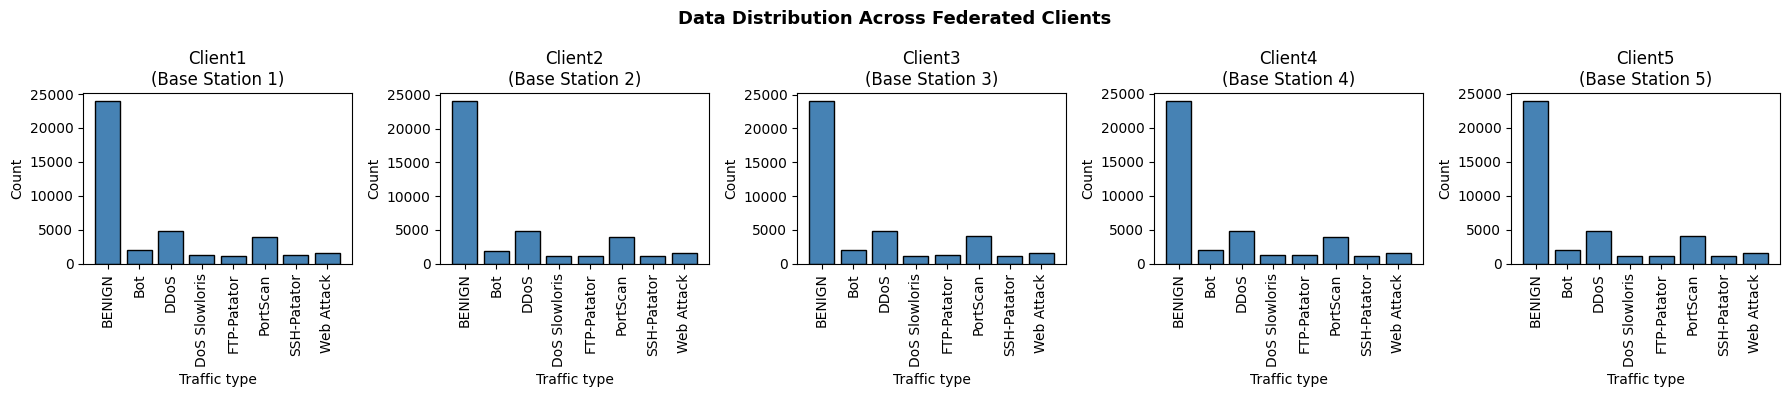

In [ ]:
fig, axes = plt.subplots(1, NUM_CLIENTS, figsize=(18,4))

for i in range(NUM_CLIENTS):
  unique, counts = np.unique(y_clients[i], return_counts=True)
  axes[i].bar(unique, counts, color='steelblue', edgecolor='black')
  axes[i].set_title(f'Client{i+1}\n(Base Station {i+1})')
  axes[i].set_xlabel('Traffic type')
  axes[i].set_ylabel('Count')
  axes[i].tick_params(axis='x', rotation=90)

plt.suptitle('Data Distribution Across Federated Clients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Saving everything and freezing the data using Pickle


In [ ]:
import pickle

#save all preprocessed data
with open('federated_data.pkl','wb') as f:
  pickle.dump({
      'X_clients': X_clients,
      'y_clients': y_clients,
      'le': le,
      'scaler': scaler,
      'feature_names': feature_names,
      'num_classes': len(le.classes_)
  }, f)
print('Phases 2 completed, Saved federated_data.pkl')
print(f'\nSummary:')
print(f" Features per sample : {X_scaled.shape[1]}")
print(f" Total samples : {len(X_scaled)}")
print(f" Number of clients : {NUM_CLIENTS}")
print(f" Attack Types : {list(le.classes_)}")


Phases 2 completed, Saved federated_data.pkl

Summary:
 Features per sample : 15
 Total samples : 200000
 Number of clients : 5
 Attack Types : ['BENIGN', 'Bot', 'DDoS', 'DoS Slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']


# Phase - 3

Load Phase 2 data

In [ ]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#loading the saved data from phase 2
with open('federated_data.pkl','rb') as f:
  data = pickle.load(f)

X_clients = data['X_clients']
y_clients = data['y_clients']
le = data['le']
feature_names = data['feature_names']
num_classes = data['num_classes']

print("Data loaded")
print(f"Number of clients: {len(X_clients)}")
print(f"Features per sample: {X_clients[0].shape[1]}")
print(f"Number of classes : {num_classes}")
print(f"Attack Types: {list(le.classes_)}")

Data loaded
Number of clients: 5
Features per sample: 15
Number of classes : 8
Attack Types: ['BENIGN', 'Bot', 'DDoS', 'DoS Slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']


Building the neural network

In [ ]:
class NIDSModel(nn.Module):
  def __init__(self, input_size, num_classes):
    super(NIDSModel, self).__init__()

    self.network = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32, num_classes)
    )

  def forward(self, x):
    return self.network(x)

input_size = X_clients[0].shape[1]
model = NIDSModel(input_size, num_classes)
print("Neural Network Built")
print(f"\nArchitecture:")
print(model)

Neural Network Built

Architecture:
NIDSModel(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [ ]:
from collections import Counter

le.fit(np.concatenate(y_clients))
y_clients = [le.transform(y) for y in y_clients]

all_y = np.concatenate(y_clients)
class_counts = Counter(all_y)

total = len(all_y)
num_cls = len(le.classes_)
weights = [total / (num_cls * class_counts[i]) for i in range(num_cls)]
class_weights = torch.FloatTensor(weights)

print("Class weights:")
for i, (name, w) in enumerate(zip(le.classes_, weights)):
    print(f"  {name:15s} → weight: {w:.2f}")

Class weights:
  BENIGN          → weight: 0.21
  Bot             → weight: 2.48
  DDoS            → weight: 1.03
  DoS Slowloris   → weight: 4.19
  FTP-Patator     → weight: 4.18
  PortScan        → weight: 1.25
  SSH-Patator     → weight: 4.21
  Web Attack      → weight: 3.10


Client training Function


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

def train_client(model, X, y, epochs=5, lr=0.001):
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.LongTensor(y.astype(int))

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    total_loss = 0

    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        total_loss = epoch_loss

    print(f"    Final loss: {total_loss:.4f}")
    return model.state_dict()

print("train_client ready!")

train_client ready!


FedAvg server


In [ ]:
def federated_averaging(client_weights):
  avg_weights = client_weights[0].copy()

  for key in avg_weights.keys():
    for i in range(1, len(client_weights)):
      avg_weights[key] += client_weights[i][key]
    avg_weights[key] = torch.div(avg_weights[key], len(client_weights))

  return avg_weights
print("FedAvg Func ready")

FedAvg Func ready


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# First fit the encoder on all labels combined
all_labels = np.concatenate(y_clients)
le.fit(all_labels)

# Now transform each client's labels to numbers
y_clients = [le.transform(y) for y in y_clients]

print(" Labels encoded and converted!")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Sample values: {y_clients[0][:5]}")

 Labels encoded and converted!
Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6), np.int64(7): np.int64(7)}
Sample values: [0 0 0 5 0]


Federated Training loop

In [ ]:
NUM_ROUNDS = 10  # Number of federated rounds
NUM_CLIENTS = len(X_clients)

# Create the global model
global_model = NIDSModel(input_size, num_classes)

print(" Starting Federated Training!")
print(f"   Clients : {NUM_CLIENTS} base stations")
print(f"   Rounds  : {NUM_ROUNDS}")
print("─" * 40)

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n Round {round_num}/{NUM_ROUNDS}")

    client_weights = []

    # Each client trains on its own data
    for client_id in range(NUM_CLIENTS):
        print(f"  Client {client_id + 1} training...", end=" ")

        # Give each client a copy of the global model
        local_model = NIDSModel(input_size, num_classes)
        local_model.load_state_dict(global_model.state_dict())

        # Train on local data
        weights = train_client(
            local_model,
            X_clients[client_id],
            y_clients[client_id]
        )
        client_weights.append(weights)

    # Server averages all weights
    global_weights = federated_averaging(client_weights)
    global_model.load_state_dict(global_weights)
    print(f"\nRound {round_num} complete — Global model updated!")

print("\nFederated Training Complete")

 Starting Federated Training!
   Clients : 5 base stations
   Rounds  : 10
────────────────────────────────────────

 Round 1/10
  Client 1 training...     Final loss: 160.0579
  Client 2 training...     Final loss: 157.6694
  Client 3 training...     Final loss: 157.8548
  Client 4 training...     Final loss: 159.9263
  Client 5 training...     Final loss: 158.0330

Round 1 complete — Global model updated!

 Round 2/10
  Client 1 training...     Final loss: 158.9546
  Client 2 training...     Final loss: 156.3648
  Client 3 training...     Final loss: 156.9023
  Client 4 training...     Final loss: 159.0785
  Client 5 training...     Final loss: 156.6813

Round 2 complete — Global model updated!

 Round 3/10
  Client 1 training...     Final loss: 158.4951
  Client 2 training...     Final loss: 156.2449
  Client 3 training...     Final loss: 156.6065
  Client 4 training...     Final loss: 158.4314
  Client 5 training...     Final loss: 156.6001

Round 3 complete — Global model updated!

### Evaluation of the client data

In [ ]:
# Combine all client data for evaluation
X_all = np.vstack(X_clients)
y_all = np.concatenate(y_clients).astype(int)

# Run predictions
global_model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_all)
    outputs = global_model(X_tensor)
    _, predictions = torch.max(outputs, 1)
    predictions = predictions.numpy()

# Define class names manually
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS Slowloris',
               'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']

print("Final Model Performance:")
print("─" * 40)
print(classification_report(y_all, predictions, target_names=class_names))

Final Model Performance:
────────────────────────────────────────
               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00    119826
          Bot       0.32      0.05      0.08     10091
         DDoS       1.00      1.00      1.00     24165
DoS Slowloris       0.20      0.25      0.22      5971
  FTP-Patator       0.19      0.42      0.26      5979
     PortScan       1.00      1.00      1.00     19954
  SSH-Patator       0.21      0.20      0.20      5942
   Web Attack       0.26      0.27      0.26      8072

     accuracy                           0.86    200000
    macro avg       0.52      0.52      0.50    200000
 weighted avg       0.86      0.86      0.85    200000



Confusion Matrix


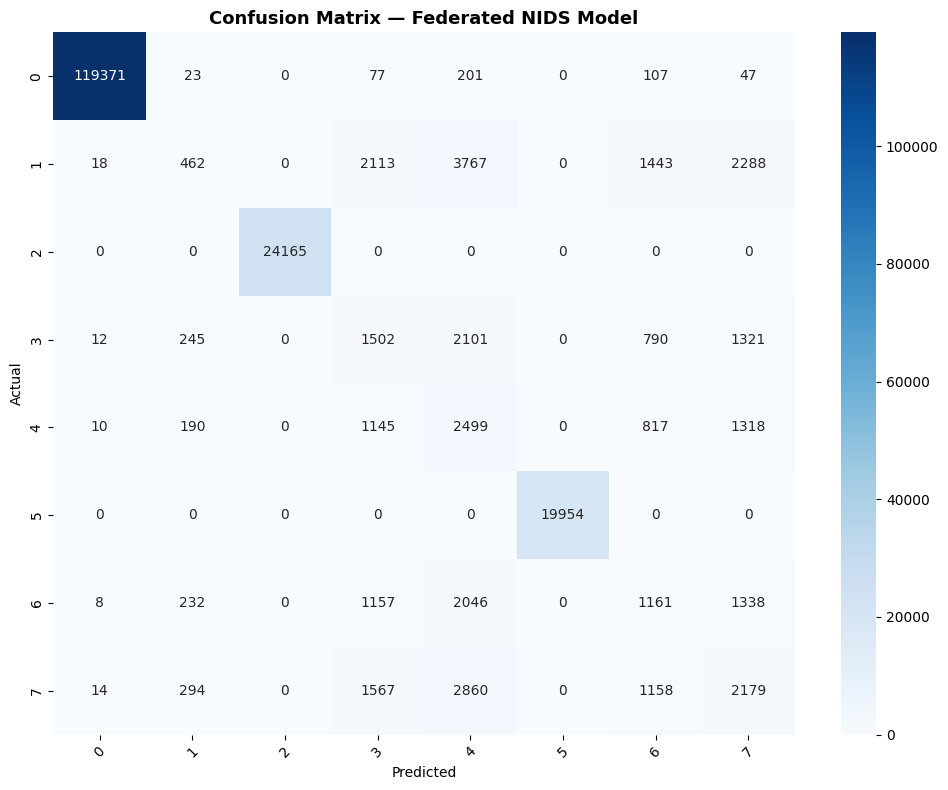

In [ ]:
cm = confusion_matrix(y_all, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Federated NIDS Model',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()